## Section 1 : Installation et chargement des données
Importation des bibliothèques nécessaires au traitement des données de santé, à la visualisation et à la création du modèle de régression logistique.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Chemin précis vers ton fichier d'après ton explorateur de fichiers
chemin = 'UCI Heart Disease Data/heart_disease_uci.csv'

# Chargement du jeu de données
df = pd.read_csv(chemin)

print("--- Dimensions du jeu de données (Lignes, Colonnes) ---")
print(df.shape)

print("\n--- Aperçu des premières lignes ---")
print(df.head())

print("\n--- Analyse de la qualité (Valeurs manquantes et Types) ---")
print(df.info())

print("\n--- Décompte des valeurs manquantes ---")
print(df.isnull().sum())

--- Dimensions du jeu de données (Lignes, Colonnes) ---
(920, 16)

--- Aperçu des premières lignes ---
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             nor

## Section 2 : Analyse exploratoire des données (EDA)
Visualisation de la répartition de la variable cible pour vérifier l'équilibre des classes et analyse de la distribution de l'âge en fonction du diagnostic.

C:\Users\adjara\AppData\Local\Temp\ipykernel_3364\2585919926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=nom_cible, palette='magma')


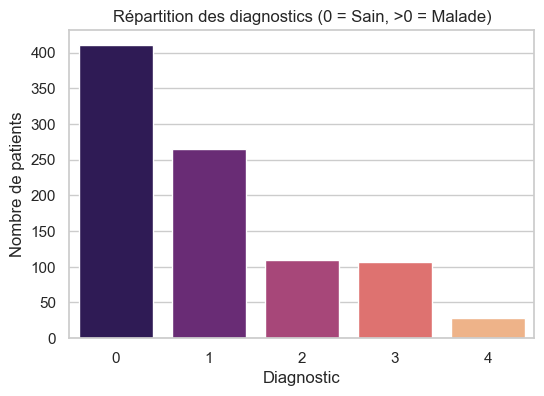

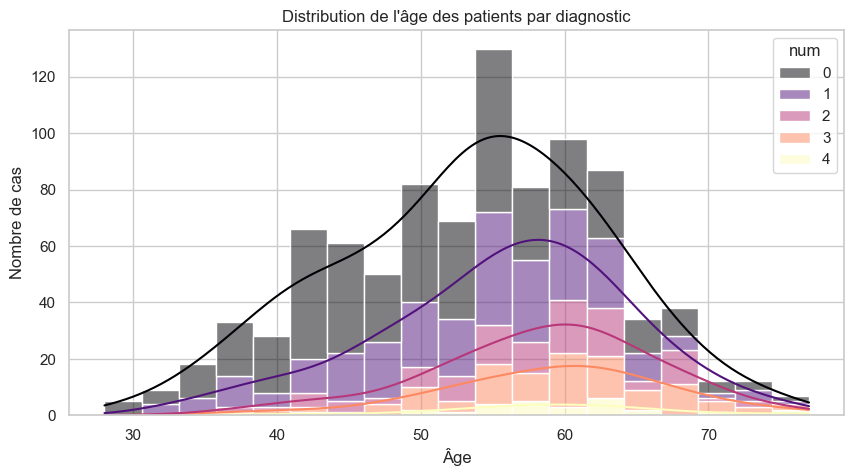

In [16]:
# Configuration du style graphique
sns.set_theme(style="whitegrid")

# On définit le nom de la colonne cible (généralement 'num' ou 'target' dans le dataset UCI)
# Si ta colonne cible s'appelle autrement, ajuste ce nom :
nom_cible = 'num' 

# 1. Distribution de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=nom_cible, palette='magma')
plt.title('Répartition des diagnostics (0 = Sain, >0 = Malade)')
plt.xlabel('Diagnostic')
plt.ylabel('Nombre de patients')
plt.show()

# 2. Distribution de l'âge selon la présence d'une maladie cardiaque
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue=nom_cible, multiple='stack', kde=True, palette='magma')
plt.title('Distribution de l\'âge des patients par diagnostic')
plt.xlabel('Âge')
plt.ylabel('Nombre de cas')
plt.show()

## Section 3 : Prétraitement des données
Gestion des valeurs manquantes, binarisation de la variable cible pour la régression logistique, encodage des variables catégorielles et séparation des données.

In [17]:
# 1. Gestion des valeurs manquantes (remplacement par la médiane pour le numérique)
colonnes_numeriques = df.select_dtypes(include=[np.number]).columns
for col in colonnes_numeriques:
    df[col] = df[col].fillna(df[col].median())

# S'il y a des colonnes textuelles manquantes, on les remplace par le mode
colonnes_categoriques = df.select_dtypes(include=['object']).columns
for col in colonnes_categoriques:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Transformation de la cible en problème binarisé (0 = sain, 1 = malade)
# Dans l'UCI standard, 0 signifie sain et les valeurs 1, 2, 3, 4 signifient différents stades de maladie.
df[nom_cible] = df[nom_cible].apply(lambda x: 1 if x > 0 else 0)

# 3. Encodage des variables catégorielles (ex: sex, dataset, cp...)
df_encoded = pd.get_dummies(df, columns=[col for col in colonnes_categoriques if col != nom_cible], drop_first=True)

# 4. Séparation en caractéristiques (X) et cible (y)
X = df_encoded.drop(columns=[nom_cible])
y = df_encoded[nom_cible]

# 5. Division Train / Test (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Standardisation des caractéristiques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Prétraitement terminé avec succès.")
print(f"Taille de l'ensemble d'entraînement : {X_train_scaled.shape}")
print(f"Taille de l'ensemble de test : {X_test_scaled.shape}")

Prétraitement terminé avec succès.
Taille de l'ensemble d'entraînement : (736, 22)
Taille de l'ensemble de test : (184, 22)


C:\Users\adjara\AppData\Local\Temp\ipykernel_3364\2760229703.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_categoriques = df.select_dtypes(include=['object']).columns


## Section 4 : Entraînement de la Régression Logistique et Évaluation
Entraînement du modèle, calcul des métriques de performance et affichage de la matrice de confusion.

--- Métriques de performance ---
Précision globale (Accuracy) : 0.8424
Précision (Precision)         : 0.8774
Rappel / Mémoire (Recall)     : 0.8532
Score F1                      : 0.8651

Rapport de classification complet :
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        75
           1       0.88      0.85      0.87       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



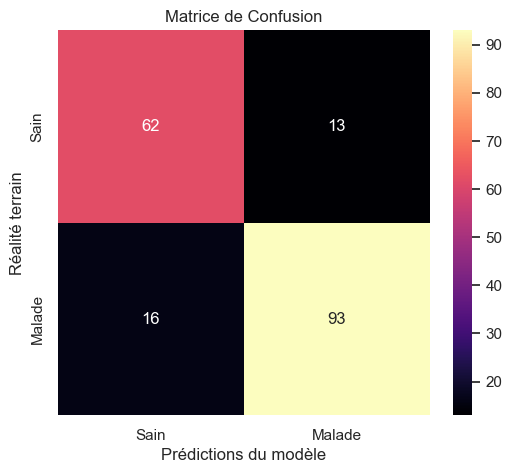

In [18]:
# 1. Entraînement du modèle de régression logistique
modele_lr = LogisticRegression(max_iter=1000, random_state=42)
modele_lr.fit(X_train_scaled, y_train)

# 2. Prédictions sur l'ensemble de test
y_pred = modele_lr.predict(X_test_scaled)

# 3. Calcul des métriques demandées
precision_globale = accuracy_score(y_test, y_pred)
precision_positive = precision_score(y_test, y_pred)
sensibilite = recall_score(y_test, y_pred)
score_f1 = f1_score(y_test, y_pred)

print("--- Métriques de performance ---")
print(f"Précision globale (Accuracy) : {precision_globale:.4f}")
print(f"Précision (Precision)         : {precision_positive:.4f}")
print(f"Rappel / Mémoire (Recall)     : {sensibilite:.4f}")
print(f"Score F1                      : {score_f1:.4f}")

# 4. Rapport de classification complet
print("\nRapport de classification complet :")
print(classification_report(y_test, y_pred))

# 5. Matrice de confusion graphique
matrice = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(matrice, annot=True, fmt='d', cmap='magma', xticklabels=['Sain', 'Malade'], yticklabels=['Sain', 'Malade'])
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions du modèle')
plt.ylabel('Réalité terrain')
plt.show()